In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("netflix_titles.csv")

print("Shape of Dataset:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:")
print(df.duplicated().sum())

Shape of Dataset: (8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicates:
0


In [11]:
df = df.drop_duplicates()

In [12]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")


In [13]:
df = df.dropna(subset=["date_added"])

In [15]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


In [16]:
df.to_csv("cleaned_netflix_titles.csv", index=False)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!


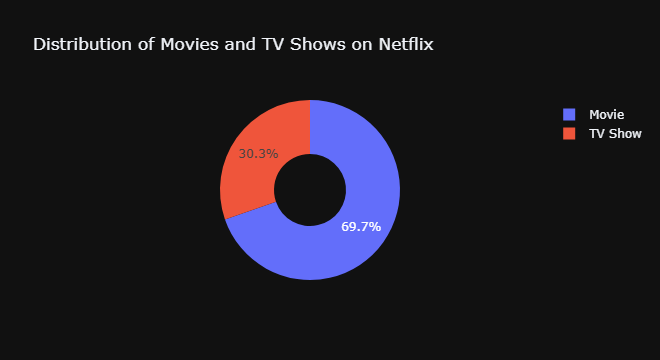

In [37]:
import plotly.express as px

content_count = df['type'].value_counts().reset_index()
content_count.columns = ['Type', 'Count']

fig = px.pie(
    content_count,
    names='Type',
    values='Count',
    title='Distribution of Movies and TV Shows on Netflix',
    hole=0.4,
    template='plotly_dark'
)

fig.show()

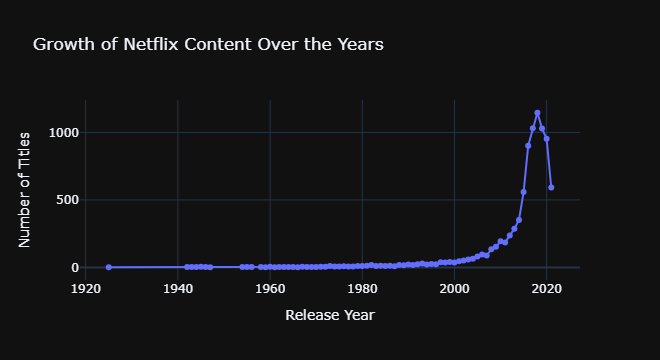

In [38]:
import plotly.express as px

year_data = (
    df['release_year']
    .value_counts()
    .sort_index()
    .reset_index()
)

year_data.columns = ['Year', 'Count']

fig = px.line(
    year_data,
    x='Year',
    y='Count',
    markers=True,
    title='Growth of Netflix Content Over the Years',
    template='plotly_dark'
)

fig.update_layout(
    xaxis_title='Release Year',
    yaxis_title='Number of Titles'
)

fig.show()

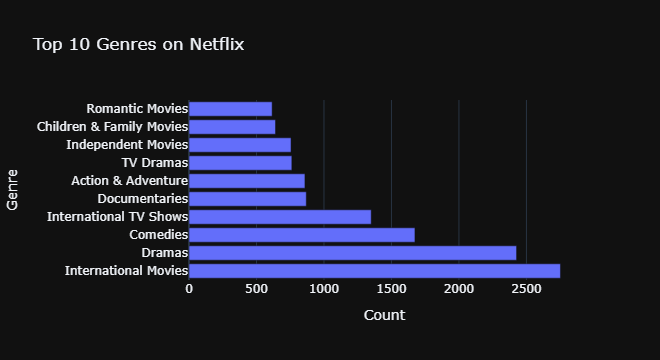

In [39]:
import plotly.express as px

genres = df['listed_in'].str.split(', ').explode()

genre_count = genres.value_counts().head(10).reset_index()
genre_count.columns = ['Genre', 'Count']

fig = px.bar(
    genre_count,
    x='Count',
    y='Genre',
    orientation='h',
    title='Top 10 Genres on Netflix',
    template='plotly_dark'
)

fig.show()

In [30]:
print("Total Titles :", len(df))
print("Movies :", len(df[df['type']=='Movie']))
print("TV Shows :", len(df[df['type']=='TV Show']))
print("Countries :", df['country'].nunique())

Total Titles : 8797
Movies : 6131
TV Shows : 2666
Countries : 749
